In [1]:
import pandas as pd

df = pd.read_csv("CLV_Dataset.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df.shape

(1067371, 8)

In [3]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [4]:
df.select_dtypes(include=['number']).corr()

,Quantity,Price,Customer ID
Quantity,1.000000,-0.001319,-0.005430
Price,-0.001319,1.000000,-0.003835
Customer ID,-0.005430,-0.003835,1.000000


In [5]:
df.describe

<bound method NDFrame.describe of         Invoice StockCode                          Description  Quantity  \
0        489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1        489434    79323P                   PINK CHERRY LIGHTS        12   
2        489434    79323W                  WHITE CHERRY LIGHTS        12   
3        489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4        489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...         ...       ...                                  ...       ...   
1067366  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
1067367  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
1067368  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
1067369  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
1067370  581587      POST                              POSTAGE         1   

                 InvoiceDate  Price  Customer ID     

In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

## Check Customer id missing values percentage out of total

In [7]:
missing_pct = df['Customer ID'].isna().mean() * 100
print(missing_pct)

22.766872999172733


## Check Pattern

In [8]:
df[df['Customer ID'].isna()]['Country'].value_counts()

Country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
RSA                         46
Bermuda                     34
Sweden                      19
Lebanon                     13
Nigeria                      2
Name: count, dtype: int64

##### I decided to drop missing Customer ID rows and keep missing value descriptions rows.

##### Missing CustomerIDs are primarily from UK transactions and likely correspond to guest checkouts or unregistered users in the online system. Since these cannot be linked to individual customers, they were excluded from CLV analysis.

##### Since product description is not required for customer-level aggregation, I chose not to prioritize imputing it, focusing instead on features relevant to CLV.

In [9]:
df = df.dropna(subset=["Customer ID"])

In [10]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [11]:
df.shape

(824364, 8)

##### After removing rows with missing CustomerID (~243k rows), I observed that missing product descriptions were also eliminated, indicating overlap between missing fields.

### Checking for duplicates

In [12]:
df.duplicated().sum()

np.int64(26479)

### Removing the duplicates

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(797885, 8)

In [15]:
df.duplicated().sum()

np.int64(0)

### Finding out and removing Cancelled invoices.

In [16]:
df[df["Invoice"].astype(str).str.startswith("C")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [17]:
df = df.drop(df[df["Invoice"].astype(str).str.startswith("C")].index)

In [18]:
df[df["Invoice"].astype(str).str.startswith("C")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


### Cancelled invoices represent product returns and contain negative quantities. Since they do not contribute to revenue generation, I excluded them to ensure accurate CLV estimation.

### Adding Revenue column (Revenue generated in each transaction)

In [19]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [20]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Identify the outliers

### I am selecting Quantity, Price & Revenue columns because they are numerical and can lead to possible outliers.

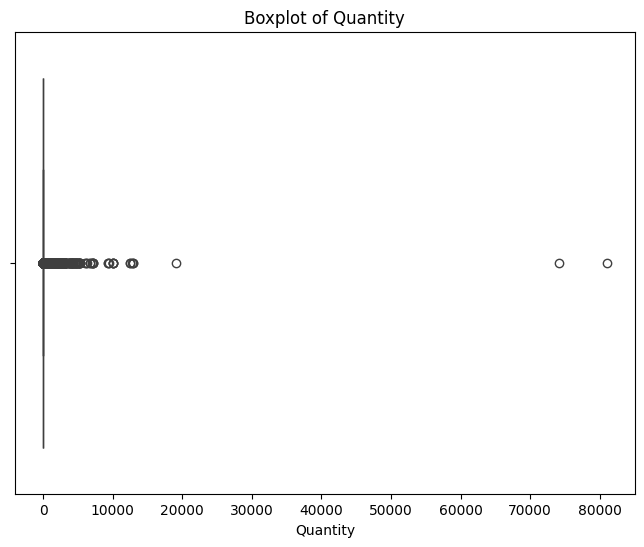

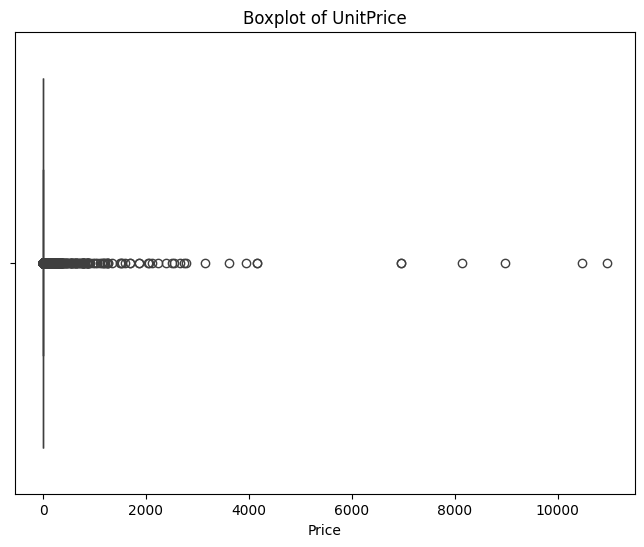

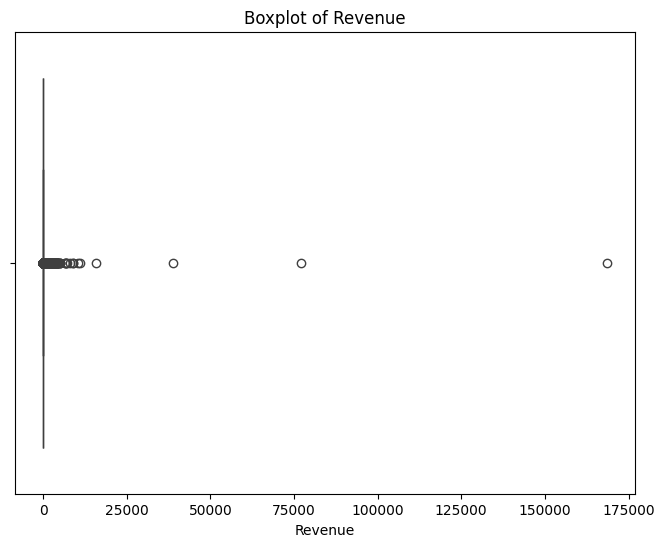

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: plot boxplot for Quantity
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Quantity'])
plt.title("Boxplot of Quantity")
plt.show()

# Example: plot boxplot for UnitPrice
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of UnitPrice")
plt.show()

# Example: plot boxplot for Revenue
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Revenue'])
plt.title("Boxplot of Revenue")
plt.show()

### Remove the outliers

In [22]:
def remove_outliers_threshold(df, column, lower=None, upper=None):
    if lower is not None:
        df = df[df[column] >= lower]
    if upper is not None:
        df = df[df[column] <= upper]
    return df

# Example usage:
df = remove_outliers_threshold(df, 'Quantity', lower=1, upper=12000)
df = remove_outliers_threshold(df, 'Price', lower=0.1, upper=3000)
df = remove_outliers_threshold(df, 'Revenue', upper=13000)

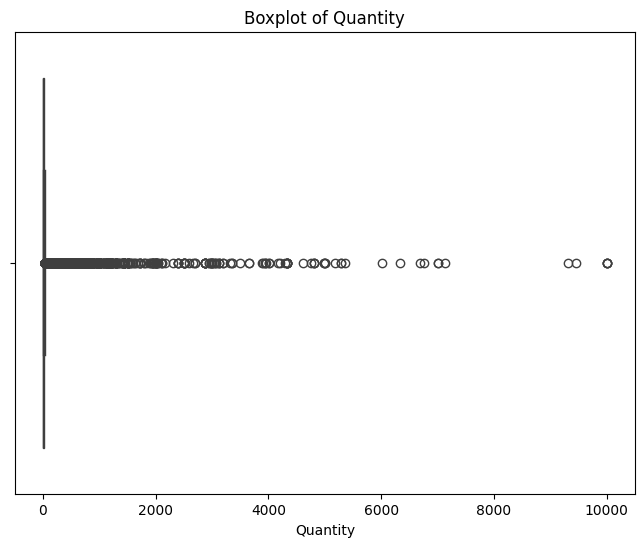

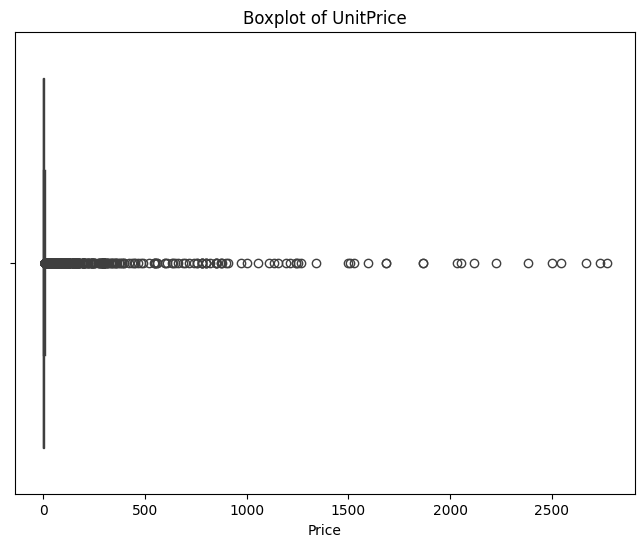

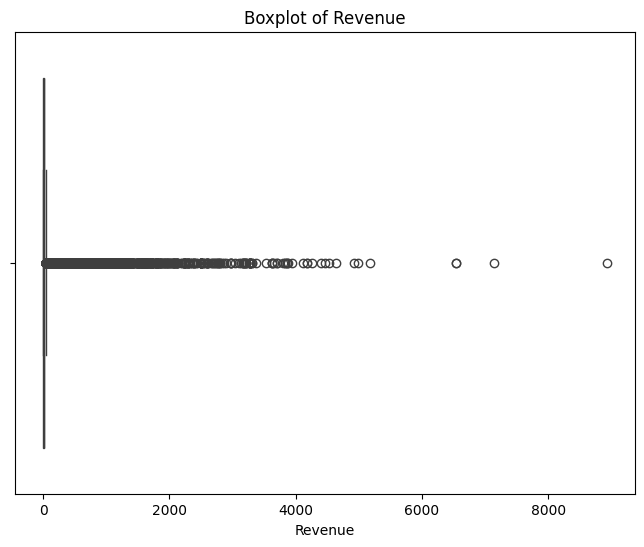

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: plot boxplot for Quantity
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Quantity'])
plt.title("Boxplot of Quantity")
plt.show()

# Example: plot boxplot for UnitPrice
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of UnitPrice")
plt.show()

# Example: plot boxplot for Revenue
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Revenue'])
plt.title("Boxplot of Revenue")
plt.show()

### After initial outlier removal, I observed additional outliers due to the skewed nature of transactional data. Instead of repeatedly removing them, I retained valid high-value transactions to preserve business signal.

### Customer-Level Aggregation (RFM Features)

In [24]:
import pandas as pd

# Reference date for recency calculation (last date in dataset)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
reference_date = df['InvoiceDate'].max()

customer_df = df.groupby('Customer ID').agg({
    'InvoiceDate': [lambda x: (reference_date - x.max()).days,  # Recency
                    lambda x: (x.max() - x.min()).days],       # Tenure
    'Invoice': 'nunique',                                    # Frequency
    'Revenue': 'sum',                                          # Monetary
}).reset_index()

# Rename columns for clarity
customer_df.columns = ['Customer ID', 'Recency', 'Tenure', 'Frequency', 'Monetary']

In [25]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [26]:
customer_df.head()

,Customer ID,Recency,Tenure,Frequency,Monetary
0,12346.0,528,196,11,372.86
1,12347.0,1,402,8,4921.53
2,12348.0,74,362,5,2019.40
3,12349.0,18,570,4,4428.69
4,12350.0,309,0,1,334.40


### EDA on RFM Features

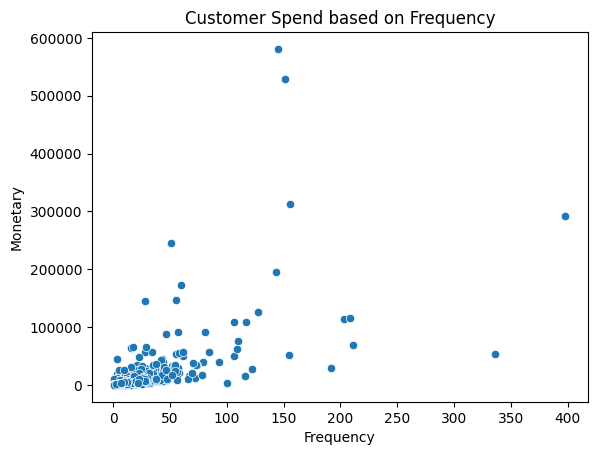

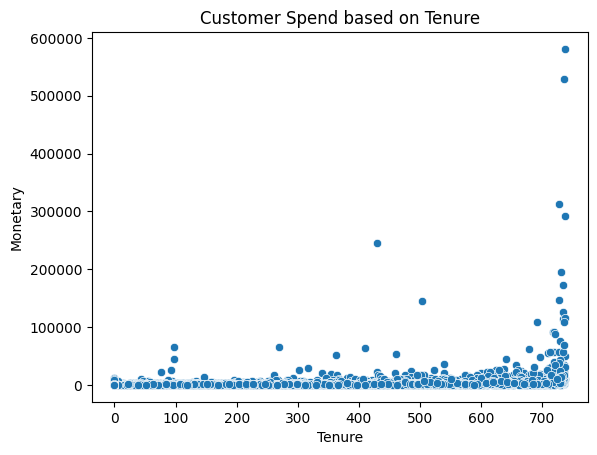

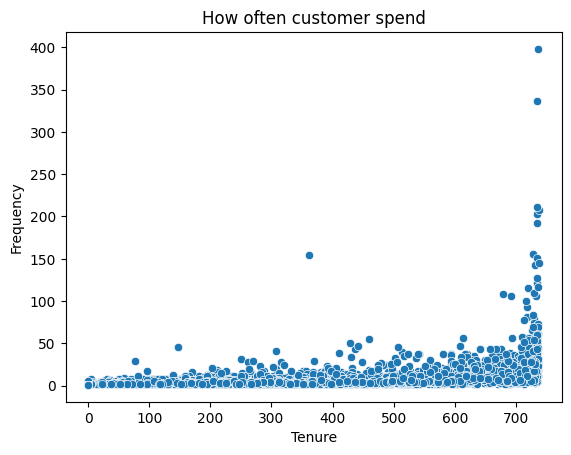

In [27]:
sns.scatterplot(x = "Frequency", y = "Monetary", data = customer_df)
plt.title("Customer Spend based on Frequency")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

sns.scatterplot(x = "Tenure", y = "Monetary", data = customer_df)
plt.title("Customer Spend based on Tenure")
plt.xlabel("Tenure")
plt.ylabel("Monetary")
plt.show()

sns.scatterplot(x = "Tenure", y = "Frequency", data = customer_df)
plt.title("How often customer spend")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

### Scatter Plot summary

##### Plot1: The analysis shows a weak positive relationship between frequency and monetary value, with most customers being low-frequency buyers. A small group of high-value customers contributes disproportionately to revenue, highlighting the importance of targeted retention strategies.

##### Plote2: The analysis shows a weak relationship between tenure and monetary value. While some long-tenure customers generate high revenue, many remain low-value. Additionally, some new customers exhibit high spending early, indicating that tenure alone is not a strong predictor of customer value.”

##### Plot3: The analysis shows that most customers have low purchase frequency, and there is no strong relationship between tenure and frequency. Some long-tenure customers remain inactive, while certain new customers exhibit high engagement early on.

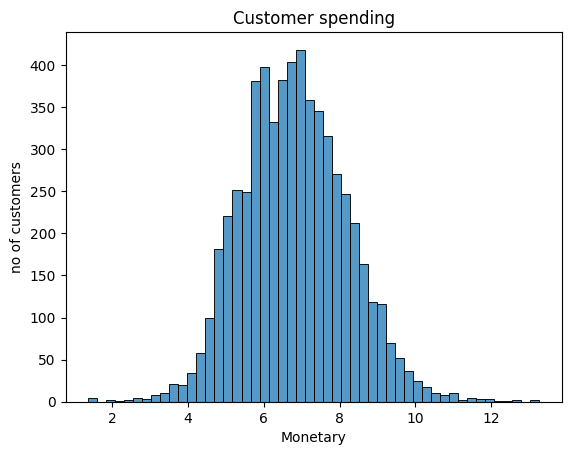

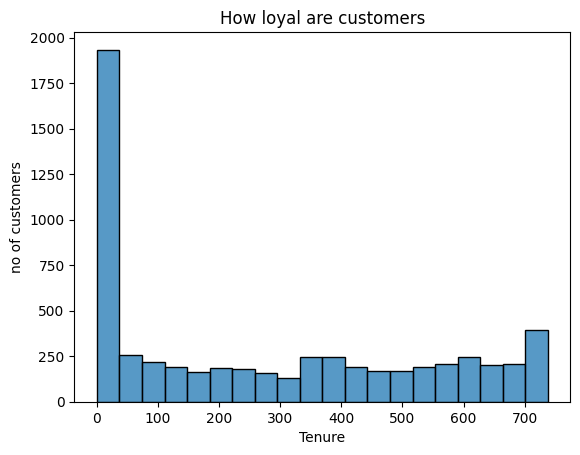

In [28]:
import numpy as np

sns.histplot(np.log1p(customer_df["Monetary"]), bins = 50)
plt.title("Customer spending")
plt.xlabel("Monetary")
plt.ylabel("no of customers")
plt.show()

sns.histplot(customer_df["Tenure"], bins = 20)
plt.title("How loyal are customers")
plt.xlabel("Tenure")
plt.ylabel("no of customers")
plt.show()

### Insights of Histogram

##### The monetary distribution was highly skewed, but after log transformation it approximates a normal distribution, revealing a clear central spending range and a small group of high-value customers.

##### The tenure distribution shows that a large portion of customers are relatively new, as indicated by the high concentration at lower tenure values. At the same time, customers are spread across the entire time range, suggesting a mix of both new and long-term users. Additionally, a smaller group of customers with very high tenure represents loyal users who have stayed with the business for a longer period.

### Define target value for CLV prediction

In [29]:
start_date = df['InvoiceDate'].min()
end_date = df['InvoiceDate'].max()

cutoff_date = start_date + (end_date - start_date) * 0.7

print("Cutoff date:", cutoff_date)

Cutoff date: 2011-05-02 01:42:30


In [30]:
train_df = df[df['InvoiceDate'] <= cutoff_date]   # 70% past data
test_df  = df[df['InvoiceDate'] > cutoff_date]    # 30% future data

# Target CLV = future spend per customer
y = test_df.groupby('Customer ID')['Revenue'].sum().reset_index()
y.columns = ['Customer ID', 'CLV']

# Merge features with target
data = pd.merge(customer_df, y, on='Customer ID', how='left')
data['CLV'] = data['CLV'].fillna(0)

In [31]:
train_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [32]:
test_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
697922,551539,20719,WOODLAND CHARLOTTE BAG,10,2011-05-03 08:40:00,0.85,12598.0,France,8.5
697923,551539,20723,STRAWBERRY CHARLOTTE BAG,10,2011-05-03 08:40:00,0.85,12598.0,France,8.5
697924,551539,23204,CHARLOTTE BAG APPLES DESIGN,20,2011-05-03 08:40:00,0.85,12598.0,France,17.0
697925,551539,20724,RED RETROSPOT CHARLOTTE BAG,20,2011-05-03 08:40:00,0.85,12598.0,France,17.0
697926,551539,22661,CHARLOTTE BAG DOLLY GIRL DESIGN,10,2011-05-03 08:40:00,0.85,12598.0,France,8.5


In [33]:
data.head()

,Customer ID,Recency,Tenure,Frequency,Monetary,CLV
0,12346.0,528,196,11,372.86,0.00
1,12347.0,1,402,8,4921.53,2486.57
2,12348.0,74,362,5,2019.40,310.00
3,12349.0,18,570,4,4428.69,1757.55
4,12350.0,309,0,1,334.40,0.00


##### We prepared the dataset for Customer Lifetime Value (CLV) prediction by defining the target variable as future customer spending.

##### First, the transaction data was converted to datetime format and sorted chronologically to preserve the time sequence of events. A cutoff date was then selected based on the dataset timeline to split the data into two parts: historical (past) data and future data. The historical data was used to compute customer-level features such as Recency, Frequency, Monetary (RFM), and Tenure.

##### Next, the future dataset (transactions after the cutoff date) was used to calculate the target variable (CLV) by aggregating total revenue per customer. This represents the amount each customer spends in the future period.

##### Finally, the RFM features were merged with the computed CLV values using a left join to ensure all customers are retained. Customers with no future transactions were assigned a CLV of zero, representing churn or inactivity.

##### Now we have dataset ready with RTFM and target value CLV, lets scale the RTFM using log transformation and standard scaler.

### Data Scaling

In [34]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Log-transform skewed features
data['Monetary_log'] = np.log1p(data['Monetary'])
data['Frequency_log'] = np.log1p(data['Frequency'])

# Select features for scaling
features = ['Recency', 'Tenure', 'Monetary_log', 'Frequency_log']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features])

# Replace with scaled DataFrame
X = pd.DataFrame(X_scaled, columns=features, index=data.index)

# Target remains CLV
y = data['CLV']

In [35]:
X.head()

,Recency,Tenure,Monetary_log,Frequency_log
0,1.566437,-0.297692,-0.642134,1.155633
1,-0.952356,0.498281,1.223046,0.800269
2,-0.603453,0.343723,0.578675,0.299411
3,-0.871104,1.147424,1.146713,0.074195
4,0.519728,-1.055025,-0.720685,-1.057668


##### We applied log transformation to Monetary and Frequency because they were highly skewed, while Recency and Tenure were relatively well-distributed and did not require transformation.

In [36]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size = 25, random_state = 42)

### Baseline model testing

##### I selected Lasso as a simple baseline model with regularization, LightGBM to capture complex non-linear patterns in customer behavior, and stacking to combine the strengths of multiple models and improve overall prediction performance.

#### Lasso regression

In [37]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(x_train, y_train)
y_pred_lasso = lasso.predict(x_test)

Lasso_RMSE = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
Lasso_R = r2_score(y_test, y_pred_lasso)

print("Lasso RMSE:",Lasso_RMSE)
print("Lasso R²:", Lasso_R)

Lasso RMSE: 1553.4827478187146
Lasso R²: -3.3155228922909856


##### Lasso performed poorly with a negative R², indicating that linear models are not suitable for capturing the complex and non-linear patterns in customer lifetime value

#### LightGBM

In [38]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgb_model.fit(x_train, y_train)
y_pred_lgb = lgb_model.predict(x_test)

LightGBM_RMSE = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
LightGBM_R = r2_score(y_test, y_pred_lgb)

print("LightGBM RMSE:",LightGBM_RMSE)
print("LightGBM R²:",LightGBM_R)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 827
[LightGBM] [Info] Number of data points in the train set: 5851, number of used features: 4
[LightGBM] [Info] Start training from score 1023.372453
LightGBM RMSE: 234.02524604188946
LightGBM R²: 0.9020631849145522


##### LightGBM significantly outperformed Lasso, achieving an R² of 0.90, as it can capture non-linear relationships and interactions in customer behavior, which linear models fail to do

#### Stacking Ensemble (Base - Lasso + Randomforest + LightGBM & META - RIDGE)

##### I used Lasso, Random Forest, and LightGBM as base models to capture linear, non-linear, and ensemble-based patterns respectively, and used Ridge as a meta-model to combine their predictions effectively and improve overall performance

In [39]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.linear_model import Lasso

# Base models
estimators = [
    ('lasso', Lasso(alpha=0.01, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('lgb', lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42))
]

# Meta-model = Ridge Regression
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0, random_state=42)
)

# Fit and predict
stack_model.fit(x_train, y_train)
y_pred_stack = stack_model.predict(x_test)

Stacking_RMSE = np.sqrt(mean_squared_error(y_test, y_pred_stack))
Stacking_R = r2_score(y_test, y_pred_stack)

print("Stacking (Ridge meta-model) RMSE:",Stacking_RMSE)
print("Stacking (Ridge meta-model) R²:", Stacking_R)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 827
[LightGBM] [Info] Number of data points in the train set: 5851, number of used features: 4
[LightGBM] [Info] Start training from score 1023.372453
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 4680, number of used features: 4
[LightGBM] [Info] Start training from score 992.575406
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 823
[LightGBM] [Info] Number of data points in the train set: 4681, number of used features: 4
[LightGBM] [Info] Start trainin

##### Although I implemented stacking to combine multiple models, it did not outperform LightGBM. Since LightGBM already captured most patterns effectively, stacking introduced unnecessary complexity and slightly reduced performance.

#### Performance comparision of Baseline models

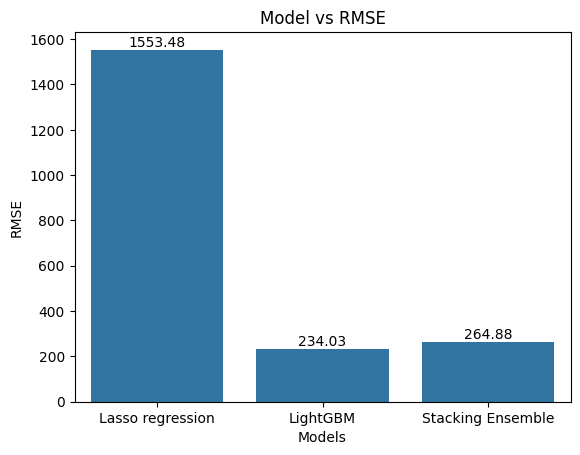

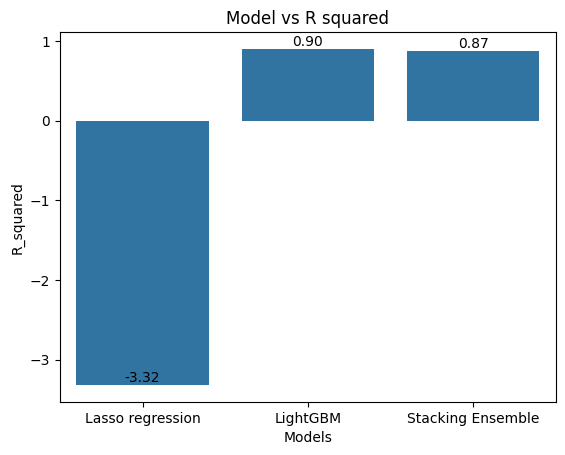

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Lasso regression","LightGBM","Stacking Ensemble"]
rmse_values = [Lasso_RMSE, LightGBM_RMSE, Stacking_RMSE]

ax = sns.barplot(x=models, y=rmse_values)

# add labels
for i, v in enumerate(rmse_values):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Model vs RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.show()

r2_values = [Lasso_R, LightGBM_R, Stacking_R]

ax = sns.barplot(x=models, y=r2_values)

# add labels
for i, v in enumerate(r2_values):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Model vs R squared")
plt.xlabel("Models")
plt.ylabel("R_squared")
plt.show()  

### Feature importance

#### Lasso regression

In [41]:
import pandas as pd

lasso_importance = pd.Series(
    lasso.coef_, index=x_train.columns
).sort_values(key=abs, ascending=False)

print("Lasso Feature Importance:")
print(lasso_importance)

Lasso Feature Importance:
Frequency_log    1932.016943
Tenure          -1709.617891
Monetary_log     1491.023348
Recency          -120.697862
dtype: float64


##### Lasso indicates that frequency and monetary value positively influence CLV, while tenure shows a negative relationship. However, due to the poor performance of the linear model, these insights are treated as indicative rather than definitive.

#### LightGBM 

In [42]:
lgb_importance = pd.Series(
    lgb_model.feature_importances_, index=x_train.columns
).sort_values(ascending=False)

print("LightGBM Feature Importance:")
print(lgb_importance)

LightGBM Feature Importance:
Monetary_log     4876
Tenure           4057
Frequency_log    3750
Recency          2317
dtype: int32


##### Feature importance analysis shows that monetary value is the strongest predictor of CLV, followed by tenure and frequency, indicating that both spending behavior and customer longevity play key roles in determining future value.

#### Stacking Ensemble

In [43]:
meta_importance = pd.Series(
    stack_model.final_estimator_.coef_, 
    index=[name for name, _ in estimators]
)

print("Stacking Meta-Model Weights:")
print(meta_importance)

Stacking Meta-Model Weights:
lasso   -0.023268
rf       1.231323
lgb     -0.189163
dtype: float64


##### The stacking model assigned the highest weight to Random Forest while reducing the contribution of LightGBM, indicating suboptimal combination of models. This resulted in lower performance compared to the standalone LightGBM model.

### Cross validation

#### we are going to perform K-Fold cross validation on each models by considering k = 5, as this is most commonly used value.

#### Lasso

In [44]:
from sklearn.model_selection import cross_val_score, KFold
# Define CV strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [45]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, random_state=42)

rmse_scores = np.sqrt(-cross_val_score(lasso, X, y, 
                                       scoring='neg_mean_squared_error', cv=cv))
r2_scores = cross_val_score(lasso, X, y, scoring='r2', cv=cv)

print("Lasso CV RMSE:", rmse_scores.mean())
print("Lasso CV R²:", r2_scores.mean())

Lasso CV RMSE: 4613.204193264317
Lasso CV R²: 0.17488700168374485


In [46]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    force_col_wise=True
)

rmse_scores = np.sqrt(-cross_val_score(lgb_model, X, y, 
                                       scoring='neg_mean_squared_error', cv=cv))
r2_scores = cross_val_score(lgb_model, X, y, scoring='r2', cv=cv)

print("LightGBM CV RMSE:", rmse_scores.mean())
print("LightGBM CV R²:", r2_scores.mean())

[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 4700, number of used features: 4
[LightGBM] [Info] Start training from score 993.903594
[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 4701, number of used features: 4
[LightGBM] [Info] Start training from score 1076.411191
[LightGBM] [Info] Total Bins 823
[LightGBM] [Info] Number of data points in the train set: 4701, number of used features: 4
[LightGBM] [Info] Start training from score 954.132948
[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 4701, number of used features: 4
[LightGBM] [Info] Start training from score 1057.373464
[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 4701, number of used features: 4
[LightGBM] [Info] Start training from score 1024.253015
[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 4700, numbe

In [47]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

estimators = [
    ('lasso', Lasso(alpha=0.01, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('lgb', lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42,verbose=-1,force_col_wise=True))
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0, random_state=42)
)

rmse_scores = np.sqrt(-cross_val_score(stack_model, X, y, 
                                       scoring='neg_mean_squared_error', cv=cv))
r2_scores = cross_val_score(stack_model, X, y, scoring='r2', cv=cv)

print("Stacking CV RMSE:", rmse_scores.mean())
print("Stacking CV R²:", r2_scores.mean())

Stacking CV RMSE: 1797.3124101662302
Stacking CV R²: 0.7782289500210096


### HyperParameter Fine tuning

#### Lasso Regression

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
import numpy as np

param_grid = {'alpha': np.logspace(-4, 2, 50)}
lasso = Lasso(random_state=42)

grid_lasso = GridSearchCV(
    lasso, param_grid, cv=5,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='neg_mean_squared_error'
)
grid_lasso.fit(x_train, y_train)

best_alpha = grid_lasso.best_params_['alpha']
best_rmse = np.sqrt(-grid_lasso.best_score_)
best_r2 = grid_lasso.cv_results_['mean_test_r2'][grid_lasso.best_index_]  # <-- underscore

print("Best Lasso alpha:", best_alpha)
print("Best Lasso RMSE:", best_rmse)
print("Best Lasso R²:", best_r2)

Best Lasso alpha: 0.03727593720314938
Best Lasso RMSE: 5074.507869129583
Best Lasso R²: 0.17310892211946355


#### LightBGM

In [49]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split
import lightgbm as lgb
import numpy as np

# 🔹 Step 1: Create validation split from training (NO shuffle for time data)
X_tr, X_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.2, shuffle=False
)

# 🔹 Step 2: Define base model
lgb_model = lgb.LGBMRegressor(random_state=42)

# 🔹 Step 3: Define parameter distributions (refined)
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05],
    'num_leaves': [31, 50, 75],
    'max_depth': [5, 10, 15],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 🔹 Step 4: Time-based cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# 🔹 Step 5: RandomizedSearchCV (optimized)
random_lgb = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=10,                      # reduced for speed
    cv=tscv,                        # time-aware CV
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,                      # use all cores
    verbose=1
)

# 🔹 Step 6: Fit model (using validation set for early stopping)
random_lgb.fit(X_tr, y_tr)

# 🔹 Step 7: Extract best results
best_params = random_lgb.best_params_
best_rmse = np.sqrt(-random_lgb.best_score_)

print("Best LightGBM params:", best_params)
print("Best CV RMSE:", best_rmse)

# 🔹 Step 8: Train final model with best params
final_model = lgb.LGBMRegressor(**best_params, random_state=42)

final_model.fit(x_train, y_train)

# 🔹 Step 9: Evaluate on test set
y_pred = final_model.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print("Final Test RMSE:", rmse_test)
print("Final Test R²:", r2_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 1170, number of used features: 4
[LightGBM] [Info] Start training from score 1147.139266
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

#### Stacking ensemble

In [50]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Base models (use tuned hyperparameters here)
lasso_best = Lasso(alpha=best_alpha, random_state=42)  # from your Lasso tuning
rf_best = RandomForestRegressor(
    n_estimators=200, max_depth=10, random_state=42
)  # adjust if you tuned RF
lgb_best = lgb.LGBMRegressor(**best_params)  # from your LightGBM tuning

# Stacking ensemble with Ridge meta-model
stack_model = StackingRegressor(
    estimators=[
        ('lasso', lasso_best),
        ('rf', rf_best),
        ('lgb', lgb_best)
    ],
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=5
)

# Fit
stack_model.fit(x_train, y_train)

# Predict
y_pred_stack = stack_model.predict(x_test)

# Evaluate
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print("Stacking Ensemble RMSE:", rmse_stack)
print("Stacking Ensemble R²:", r2_stack)

Stacking Ensemble RMSE: 299.91152062681135
Stacking Ensemble R²: 0.8391552636282076


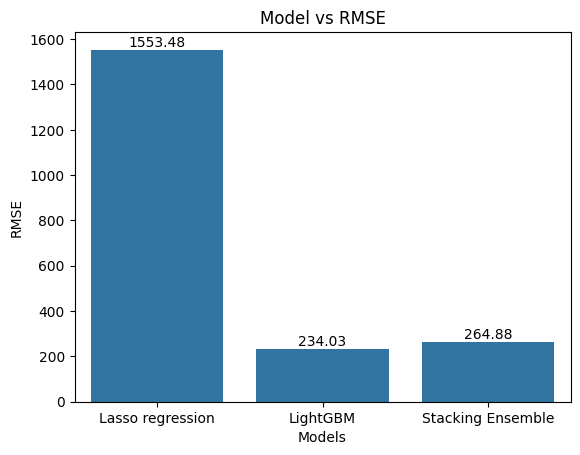

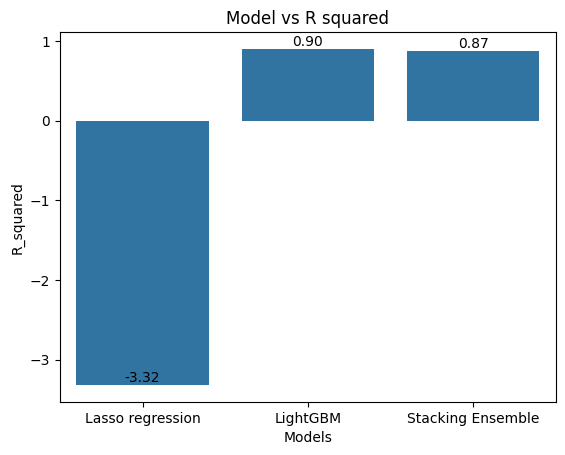

In [51]:
models = ["Lasso regression","LightGBM","Stacking Ensemble"]
rmse_values = [Lasso_RMSE, LightGBM_RMSE, Stacking_RMSE]

ax = sns.barplot(x=models, y=rmse_values)

# add labels
for i, v in enumerate(rmse_values):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Model vs RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.show()

r2_values = [Lasso_R, LightGBM_R, Stacking_R]

ax = sns.barplot(x=models, y=r2_values)

# add labels
for i, v in enumerate(r2_values):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Model vs R squared")
plt.xlabel("Models")
plt.ylabel("R_squared")
plt.show()  

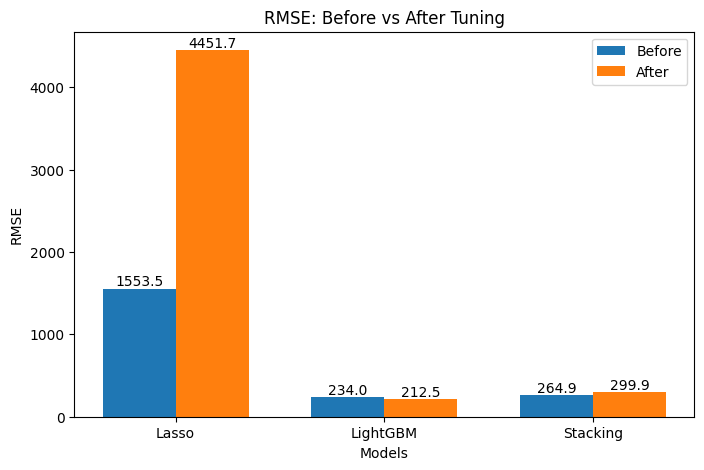

In [52]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Lasso", "LightGBM", "Stacking"]

# Values
rmse_before = [Lasso_RMSE, LightGBM_RMSE, Stacking_RMSE]
rmse_after = [best_rmse, rmse_test, rmse_stack]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, rmse_before, width, label='Before')
bars2 = ax.bar(x + width/2, rmse_after, width, label='After')

# Labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.1f}", ha='center', va='bottom')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.1f}", ha='center', va='bottom')

ax.set_title("RMSE: Before vs After Tuning")
ax.set_xlabel("Models")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.show()

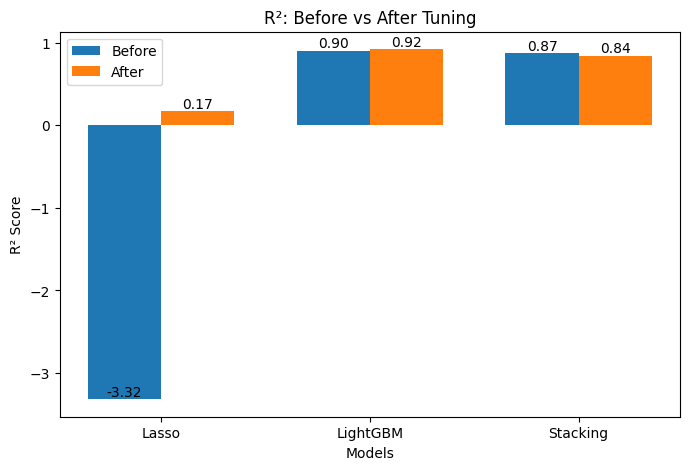

In [53]:
r2_before = [Lasso_R, LightGBM_R, Stacking_R]
r2_after = [best_r2, r2_test, r2_stack]

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, r2_before, width, label='Before')
bars2 = ax.bar(x + width/2, r2_after, width, label='After')

# Labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.2f}", ha='center', va='bottom')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.2f}", ha='center', va='bottom')

ax.set_title("R²: Before vs After Tuning")
ax.set_xlabel("Models")
ax.set_ylabel("R² Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.show()

### Customer Segmentation

In [55]:
features = ['Recency', 'Tenure', 'Monetary_log', 'Frequency_log', 'CLV']

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[features])

# Replace with scaled DataFrame
Scaled_data = pd.DataFrame(data_scaled, columns=features, index=data.index)

In [56]:
Scaled_data.head()

,Recency,Tenure,Monetary_log,Frequency_log,CLV
0,1.566437,-0.297692,-0.642134,1.155633,-0.185490
1,-0.952356,0.498281,1.223046,0.800269,0.266162
2,-0.603453,0.343723,0.578675,0.299411,-0.129183
3,-0.871104,1.147424,1.146713,0.074195,0.133745
4,0.519728,-1.055025,-0.720685,-1.057668,-0.185490


### GMM clustering

In [60]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 🔹 Step 1: Select features
features = ['Recency', 'Tenure', 'Monetary_log', 'Frequency_log', 'CLV']

# 🔹 Step 2: Scale data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[features])

Scaled_data = pd.DataFrame(data_scaled, columns=features, index=data.index)

# 🔹 Step 3: Find optimal number of clusters using BIC & AIC
bic_scores = []
aic_scores = []

for k in range(2, 10):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='diag',   # ✅ improved
        random_state=42
    )
    gmm.fit(Scaled_data)
    bic_scores.append(gmm.bic(Scaled_data))
    aic_scores.append(gmm.aic(Scaled_data))

# 🔹 Step 4: Select best k
best_k = np.argmin(bic_scores) + 2
print("Optimal number of clusters (BIC):", best_k)

# 🔹 Step 5: Fit final GMM model
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type='diag',
    random_state=42
)

gmm_final.fit(Scaled_data)

# 🔹 Step 6: Predict clusters
clusters = gmm_final.predict(Scaled_data)
probabilities = gmm_final.predict_proba(Scaled_data)

# 🔹 Step 7: Add cluster labels to original data
data['Cluster'] = clusters

# 🔹 Step 8: Cluster profiling (MOST IMPORTANT)
cluster_summary = data.groupby('Cluster')[features].mean()
print("\nCluster Summary:")
print(cluster_summary)

# 🔹 Step 9: Cluster size distribution
print("\nCluster Counts:")
print(data['Cluster'].value_counts())

Optimal number of clusters (BIC): 9

Cluster Summary:
            Recency      Tenure  Monetary_log  Frequency_log           CLV
Cluster                                                                   
0        384.011401  240.514658      7.089117       1.710745      0.039414
1         36.061404  365.952632      8.219435       2.201979   2294.365877
2         67.802832  550.540305      7.585427       2.102442    600.083867
3         13.909091  689.609756      8.841929       2.945869   2567.637073
4         78.420039    0.000000      5.528589       0.693147    339.656185
5        485.356364    0.000000      5.371052       0.693147      0.008273
6          6.202128  636.638298     10.519861       3.894906  24487.709149
7         71.195143  272.705984      6.460059       1.343949    438.696565
8        425.827133  125.711160      6.169717       1.098612      0.040963

Cluster Counts:
Cluster
7    1153
5    1100
2     918
0     614
1     570
4     519
8     457
3     451
6      94
Name: 

In [62]:
customer_df.columns

Index(['Customer ID', 'Recency', 'Tenure', 'Frequency', 'Monetary', 'Cluster'], dtype='str')

In [65]:
cluster_summary = customer_df.groupby('Cluster')[['Monetary','Frequency','Recency','Tenure']].mean()
cluster_summary = cluster_summary.sort_values(by='Monetary', ascending=False)
print(cluster_summary)

              Monetary   Frequency     Recency      Tenure
Cluster                                                   
6        451457.936667  115.666667    2.666667  634.000000
3         39769.845600   52.128000   10.464000  624.816000
1          4737.305605   11.611111   23.087654  377.817284
2          4076.047839   11.295482   44.897436  640.711844
0          1805.843098    4.990977  371.959398  267.421053
7          1006.143526    3.913769   80.525730  338.936718
8           804.548305    2.154791  449.680590   69.773956
5           319.510027    1.000000  483.845109    0.000000
4           314.595109    1.000000   78.411881    0.000000


In [66]:
cluster_map = {
    6: "High Value",
    3: "High Value",
    
    1: "Medium Value",
    2: "Medium Value",
    
    0: "Low Value",
    7: "Low Value",
    8: "Low Value",
    5: "Low Value",
    4: "Low Value"
}

customer_df['Segment'] = customer_df['Cluster'].map(cluster_map)

In [71]:
customer_df.head()

,Customer ID,Recency,Tenure,Frequency,Monetary,Cluster,Segment
0,12346.0,528,196,11,372.86,0,Low Value
1,12347.0,1,402,8,4921.53,1,Medium Value
2,12348.0,74,362,5,2019.40,7,Low Value
3,12349.0,18,570,4,4428.69,1,Medium Value
4,12350.0,309,0,1,334.40,5,Low Value


In [68]:
print(customer_df['Segment'].value_counts())

Segment
Low Value       4119
Medium Value    1629
High Value       128
Name: count, dtype: int64


In [69]:
segment_summary = customer_df.groupby('Segment')[['Monetary','Frequency','Recency','Tenure']].mean()
print(segment_summary)

                  Monetary  Frequency     Recency      Tenure
Segment                                                      
High Value    49418.785234  53.617188   10.281250  625.031250
Low Value       846.511486   2.775674  271.894149  168.396213
Medium Value   4404.850043  11.452425   34.052793  509.990792


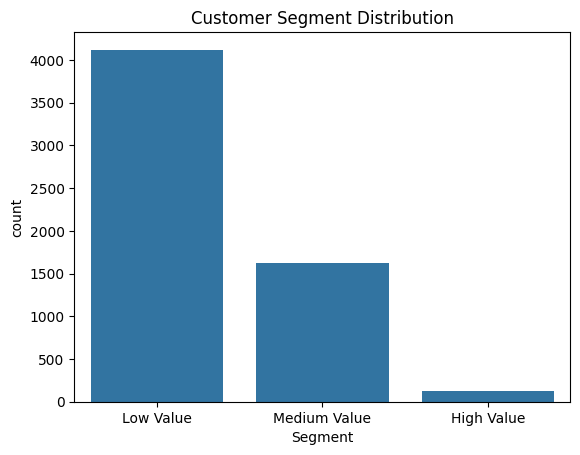

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=customer_df)
plt.title("Customer Segment Distribution")
plt.show()

### Final project Summary

##### In this project, an end-to-end Customer Lifetime Value (CLV) prediction and customer segmentation pipeline was developed using transactional data. The dataset was first cleaned by handling missing values, removing duplicate and canceled transactions, and treating outliers to ensure data quality.

##### Customer-level features were engineered by aggregating transactions and creating key behavioral metrics including Recency, Frequency, Monetary (RFM), and Tenure. CLV was defined as future customer spend using a time-based split, ensuring a realistic prediction framework.

##### Multiple models were evaluated, including Lasso, LightGBM, and a stacking ensemble. Lasso showed weak performance (R² ≈ 0.17), while LightGBM significantly outperformed other models (baseline R² ≈ 0.90). Stacking did not improve performance further (R² ≈ 0.84). Cross-validation was explored for evaluation, and a time-aware validation strategy was adopted to maintain data integrity.

##### Hyperparameter tuning was performed using RandomizedSearch with TimeSeriesSplit, improving the final LightGBM model performance to RMSE ≈ 212 and R² ≈ 0.92. Feature importance analysis identified Monetary, Tenure, and Frequency as the key drivers of customer value.

##### Finally, customer segmentation was performed using Gaussian Mixture Models (GMM), identifying multiple clusters which were consolidated into high, medium, and low-value customer segments based on behavioral patterns. This enables actionable business insights for targeted marketing and customer retention strategies.